In [1]:
pip install quimb

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install quimb

Consideramos sistemas unidimensionales de espín 1/2 con unitarios de Floquet de la forma:
$$ U = exp(-i t_0H_{MBL}) exp(-it_1 \sum_i σ_i^x) $$


Necesitamos expresar de forma correcta a U

En este programa utilizaremos el método numérico de TEBD (Time-Evolving Block-decimation) para simular la evolución temporal del sistema de muchos en una dimensión.
Este método se desarrolla a partir de Estados de Producto de Matriz (MPS)

In [3]:
import quimb as qu
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

In [4]:
# --------------------------------
# 1.Definimos los parámetros del sistema
# --------------------------------
L = 100  #número de spines 
theta = np.pi / 8  
t0 = 1.0
t1 = np.pi / 2
hz_max = 0.3  
J = 1.0
n_pasos = 20
max_bond = 50         # Dimensión de enlace chi=50 usada en la referencia, este parámetro nos limita la cantidad de entrelazamiento bipartito que la cadena de spines puede soportar
                      #las matrices locales se truncan para que nunca superen un tamaño de 50x50
cutoff = 1e-10       #Este parámetro establece un umbral para truncar los valores pequeños en las matrices


# --------------------------------
# 2.Definimos el estado inicial como MPS
# --------------------------------
#definimos el estado local directamente
# cos(theta)|0> + sin(theta)|1>
state_0 = np.array([1, 0])
state_1 = np.array([0, 1])
single_site_state = np.cos(theta) * state_0 + np.sin(theta) * state_1

#creamos el MPS a partir de los estados locales
arrays = [single_site_state for _ in range(L)]
psi = qtn.MPS_product_state(arrays)


# --------------------------------
# 3. Hamiltoniano MBL (Solo la parte estática)
# --------------------------------
rng = np.random.default_rng(None)  # Generador de números aleatorios, podemos colocar una semilla para reproducir resultados
H2 = {}   # Parte de interacción
H1 = {}   # Parte de campos locales

for i in range(L - 1):  
    J_i = rng.uniform(J / 2, 3 * J / 2)   #Fuerza de acoplamiento
    H2[(i, i + 1)] = J_i * (qu.pauli('Z') & qu.pauli('Z')) #Nos da el término de interacción de todos los elementos de la cadena 

for i in range(L): #Nos da el término de campo local para cada elemento de la cadena
    h_i = rng.uniform(0., hz_max)  #El término h_i es el campo magnético local que apunta en la dirección Z. Se elige aleatoriamente en el intervalo [0, hz_max]
    H1[i] = h_i * qu.pauli('Z')

#Esta aleatoriedad es la que induce la Localización de Muchos Cuerpos (MBL). Al tener un campo magnético de intensidad diferente y aleatoria en cada sitio,
#  el sistema pierde su simetría de traslación espacial, lo que impide que la energía y la información fluyan libremente por la cadena. 
#Esto evita que el sistema se termalice, permitiendo que la "memoria" del estado inicial (el cristal de tiempo) sobreviva.

#Este hamiltoniano solo se usará para la fase t0 del ciclo
ham = qtn.LocalHam1D(L=L, H2=H2, H1=H1)



# --------------------------------
# 4.Operador del pulso global en X
# --------------------------------
# exp(i * t1 * X) como se define en la referencia
Ux = expm(1j * t1 * qu.pauli('X'))

In [6]:
# --------------------------------
# 5.Evolución de Floquet por ciclos
# --------------------------------
mag_hist = []
S_ent = []
mag_hist_X = []

print("Iniciando evolución de Floquet...")
for paso in range(1, n_pasos + 1):

    # FASE 1: Aplicar el pulso global de espín (X)
    # Aplicamos la matriz Ux a cada sitio del MPS de forma local
    for i in range(L):
        psi.gate_(Ux, i, contract='swap+split')

    # Comprimimos el estado para mantener la dimensión de enlace bajo control
    psi.compress(max_bond=max_bond, cutoff=cutoff)

    # FASE 2: Evolución bajo H_MBL por un tiempo t0
    # Iniciamos TEBD solo para este fragmento de tiempo dándole los parámetros necesarios
    tebd = qtn.TEBD(
        psi,
        ham,
        split_opts={'max_bond': max_bond, 'cutoff': cutoff}
    )

    # Evolucionamos. El dt sugerido en el paper es 0.01*T
    tebd.update_to(t0, dt=0.01)

    # Actualizamos nuestra variable de estado
    psi = tebd.pt


    # MEDICIONES
    # ⟨σᶻ⟩ en el sitio central calculado como el producto interno <ψ|σᶻ|ψ>
    # psi.gate() aplica la matriz Z devolviendo un nuevo estado temporal
    # psi.H es el conjugado transpuesto (bra) <ψ|

    psi_Z = psi.gate(qu.pauli('Z'), L // 2)
    mz = psi.H @ psi_Z

    psi_X = psi.gate(qu.pauli('X'), L // 2)
    mx = psi.H @ psi_X


    mag_hist.append(np.real(mz))

    mag_hist_X.append(np.real(mx))
    # Entropía de entrelazamiento (tomamos la mitad de la cadena)
    S_half = psi.entropy(L // 2)
    S_ent.append(S_half)

    print(f"Paso {paso}/{n_pasos} completado. ⟨σᶻ⟩ = {np.real(mz):.3f}")


Iniciando evolución de Floquet...


t=1, max-bond=2: 100%|##########| 100/100 [00:16<00:00,  5.95%/s]


Paso 1/20 completado. ⟨σᶻ⟩ = 0.707


t=1, max-bond=2: 100%|##########| 100/100 [00:17<00:00,  5.83%/s]


Paso 2/20 completado. ⟨σᶻ⟩ = -0.707


...

Paso 18/20 completado. ⟨σᶻ⟩ = -0.707


t=1, max-bond=2: 100%|##########| 100/100 [00:17<00:00,  5.88%/s]


Paso 19/20 completado. ⟨σᶻ⟩ = 0.707


t=1, max-bond=2: 100%|##########| 100/100 [00:16<00:00,  5.91%/s]

Paso 20/20 completado. ⟨σᶻ⟩ = -0.707


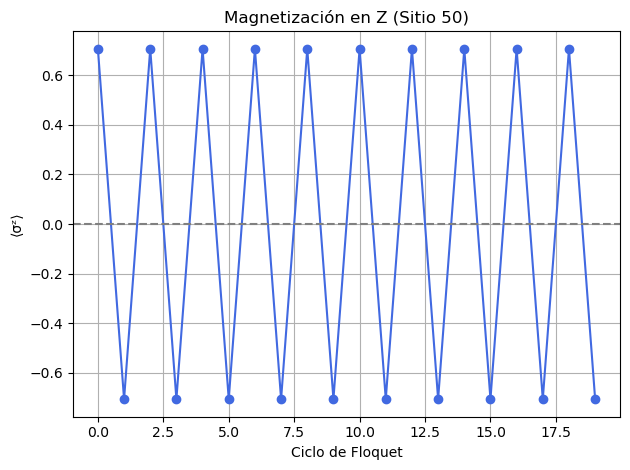

In [7]:
# --------------------------------
# 6. Graficar resultados
# --------------------------------

plt.plot(mag_hist, marker='o', color='royalblue')
plt.axhline(0, color='gray', linestyle='--')
plt.title(f'Magnetización en Z (Sitio {L//2})')
plt.xlabel('Ciclo de Floquet')
plt.ylabel('⟨σᶻ⟩')
plt.grid(True)

plt.tight_layout()
plt.show()


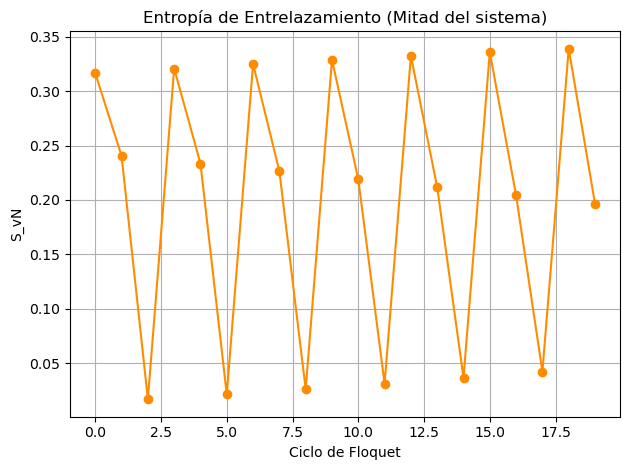

In [8]:
plt.plot(S_ent, marker='o', color='darkorange')
plt.title('Entropía de Entrelazamiento (Mitad del sistema)')
plt.xlabel('Ciclo de Floquet')
plt.ylabel('S_vN')
plt.grid(True)

plt.tight_layout()
plt.show()

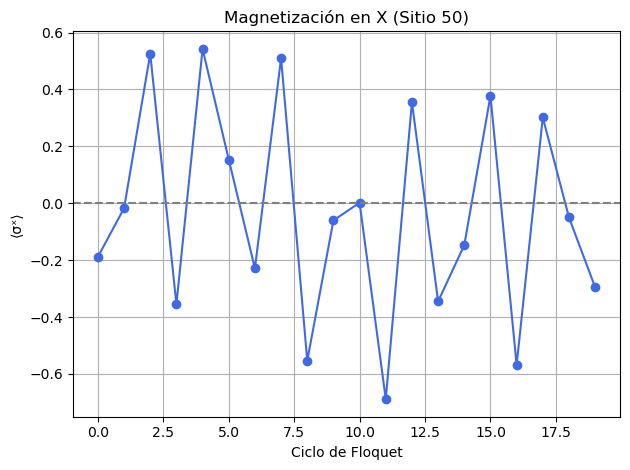

In [13]:
plt.plot(mag_hist_X, marker='o', color='royalblue')
plt.axhline(0, color='gray', linestyle='--')
plt.title(f'Magnetización en X (Sitio {L//2})')
plt.xlabel('Ciclo de Floquet')
plt.ylabel('⟨σˣ⟩')      
plt.grid(True)

plt.tight_layout()
plt.show()


\sigma^X

"Caracterización de las transciciones de fase"


Para caracterizar las transiciones de fase entre el Cristal de Tiempo (TTSB) y la Fase Termal, necesitamos replicar la métrica clave del artículo: la magnetización promediada sobre el desorden $Z(t)$.

Esta magnetización alcanza una meseta que sobrevive por un tiempo que diverge exponencialmente con el tamaño del sistema. Si la perturbación (por ejemplo, el campo transversal $h_x$) es demasiado fuerte, el sistema se termaliza, las resonancias proliferan y la magnetización decae a cero rápidamente.

Para lograr ver estas propiedades tenemos que cumplir tres puntos importantes:
1) una función central que ejecute un ciclo completo de $TEBD$ para una configuración
2) un bucle de desorden que promedie los resultados sobre diferentes semillas aleatorias  
3) un barrido de parámetros (barriendo $h_x$, $J$ o $L$) para observar cómo se colapsa la meseta

In [1]:
import quimb as qu
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

def simulacion_mbl_floquet(L, t0, t1, J, hz_max, hx_max, n_pasos, max_bond, cutoff, seed):
    """
    Ejecuta la evolución de Floquet para UNA sola realización de desorden
    y devuelve la magnetización escalonada Z(t).
    """
    rng = np.random.default_rng(seed)
    
    # 1. Estado inicial: Estado producto aleatorio en la base Z 
    # Elegimos aleatoriamente |0> (up) o |1> (down)
    bitstring = ''.join(rng.choice(['0', '1'], size=L))  #necesitamos que la cadena de espines tenga un estado inicial bien definido.
    psi = qtn.MPS_computational_state(bitstring)  #Esto genera un estado puro donde cada espín está perfectamente definido en el eje Z, sin entrelazamiento cuántico inicial
                                                  #el cálculo de la magnetización parte de estados iniciales que son productos aleatorios polarizados en la dirección Z
    
    # Magnetización inicial en el sitio central para normalizar Z(t)
    mz_inicial = np.real(psi.H @ psi.gate(qu.pauli('Z'), L // 2))  #Como acabamos de crear un estado producto sin superposiciones, este valor será numéricamente casi idéntico a 
                                                                     # +1.0 (si el espín cayó en '0') o -1.0 (si el espín cayó en '1').
    signo_inicial = np.sign(mz_inicial) if mz_inicial != 0 else 1  #Extrae únicamente el signo de esa magnetización
       
     # 2. Construcción del Hamiltoniano estático MBL
    H2 = {} # Interacciones de tipo ZZ
    H1 = {} # Interacciones de tipo Z
    for i in range(L - 1):
        J_i = rng.uniform(J / 2, 3 * J / 2)
        H2[(i, i + 1)] = J_i * (qu.pauli('Z') & qu.pauli('Z'))

    for i in range(L):
        hz_i = rng.uniform(0., hz_max)
        # Aquí introducimos la perturbación h_x en el Hamiltoniano estático
        hx_i = rng.uniform(0., hx_max) 
        H1[i] = hz_i * qu.pauli('Z') + hx_i * qu.pauli('X')

    ham = qtn.LocalHam1D(L=L, H2=H2, H1=H1)
    
    # 3. Pulso Global en X
    Ux = expm(1j * t1 * qu.pauli('X'))  #Esta pequeña matriz 2x2 representa la perturbación estroboscópica. Cuando $t_1 \approx \pi/2, 
                                         #este operador actúa como un espejo cuántico, invirtiendo perfectamente la orientación de cualquier espín individual sobre el que se aplique.
    # 4. Evolución
    Z_t = []  # Aquí almacenaremos la magnetización en cada paso

    
    for paso in range(1, n_pasos + 1):
        # Fase 1: Pulso
        for i in range(L):
            psi.gate_(Ux, i, contract='swap+split')   #psi.gate_() aplica la contracción y sobreescribe directamente en la memoria de psi. Queremos que el estado físico mute y avance al siguiente paso de la simulación.
        psi.compress(max_bond=max_bond, cutoff=cutoff)   #.compress nos ayuda a mantener la red tensorial manejable. Internamente se hace una descomposición en valores singulares y aplica los dos filtros 
                                                        # para hacer que los pesos de entrelazamiento más pequeños se eliminen y achicar la matriz aún más 

        # Fase 2: Evolución MBL
        tebd = qtn.TEBD(psi, ham, split_opts={'max_bond': max_bond, 'cutoff': cutoff}) #El sistema evoluciona libremente bajo el hamiltoniano estático (H_{MBL}). EL objeto TEBD utiliza aproximación de Trotter cortando el tiempo total t_0 en fragmentos de dt = 0.01T
        tebd.update_to(t0, dt=0.01) # dt = 0.01T sugerido por los autores
        psi = tebd.pt  #se extrae el nuevo estado
        
        # Calcular Z(t) = (-1)^t * <σ^z(t)> * sgn(<σ^z(0)>)
        mz_actual = np.real(psi.H @ psi.gate(qu.pauli('Z'), L // 2))
        Z_val = ((-1)**paso) * mz_actual * signo_inicial
        Z_t.append(Z_val)
        
    return np.array(Z_t)


Al multiplicar la evolución de cada trayectoria individual por su signo_inicial, se forza matemáticamente a que todas las trayectorias arranquen desde +1 en la gráfica. Así, cuando se promedien al final del experimento, todas oscilarán en fase y se podrá observar cómo decae la envolvente de la magnetización sin que se auto-cancelen por culpa de sus estados iniciales aleatorios.

Evaluando perturbación h_x = 0.0...


t=1, max-bond=1: 100%|##########| 100/100 [00:02<00:00, 39.80%/s]  


Evaluando perturbación h_x = 0.3...


t=1, max-bond=4: 100%|##########| 100/100 [00:02<00:00, 39.62%/s]  


Evaluando perturbación h_x = 0.8...


t=1, max-bond=23: 100%|##########| 100/100 [00:03<00:00, 29.58%/s]  


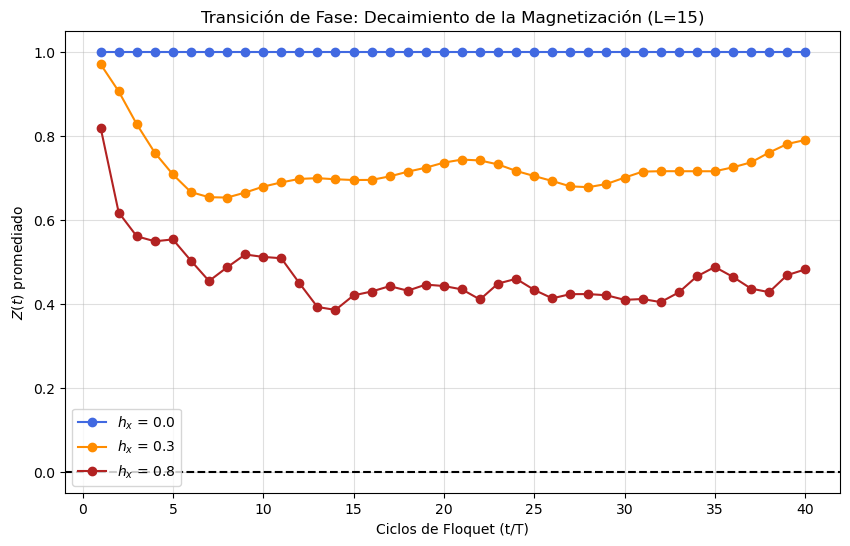

In [2]:
# ==========================================
# EXPERIMENTO: Barrido de la perturbación h_x
# ==========================================
L = 15
t0 = 1.0
t1 = np.pi / 2
J = 1.0
hz_max = 1.0
n_pasos = 40
realizaciones_desorden = 30 # Aumentar a 100+ para el reporte final

# Valores de perturbación a evaluar
hx_vals = [0.0, 0.3, 0.8] 
colores = ['royalblue', 'darkorange', 'firebrick']

plt.figure(figsize=(10, 6))

for hx, color in zip(hx_vals, colores):
    print(f"Evaluando perturbación h_x = {hx}...")
    Z_promedio = np.zeros(n_pasos)
    
    for semilla in range(realizaciones_desorden):
        Z_trayectoria = simulacion_mbl_floquet(
            L=L, t0=t0, t1=t1, J=J, hz_max=hz_max, hx_max=hx, 
            n_pasos=n_pasos, max_bond=50, cutoff=1e-8, seed=semilla
        )
        Z_promedio += Z_trayectoria
        
    Z_promedio /= realizaciones_desorden
    
    plt.plot(range(1, n_pasos + 1), Z_promedio, marker='o', color=color, label=f'$h_x$ = {hx}')

plt.axhline(0, color='black', linestyle='--')
plt.title(f'Transición de Fase: Decaimiento de la Magnetización (L={L})')
plt.xlabel('Ciclos de Floquet (t/T)')
plt.ylabel('$Z(t)$ promediado')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

Evaluando perturbación h_x = 0.1...


t=1, max-bond=2: 100%|##########| 100/100 [00:02<00:00, 38.63%/s]   


Evaluando perturbación h_x = 0.3...


t=1, max-bond=4: 100%|##########| 100/100 [00:02<00:00, 37.81%/s]   


Evaluando perturbación h_x = 0.8...


t=1, max-bond=28: 100%|##########| 100/100 [00:03<00:00, 26.01%/s]  


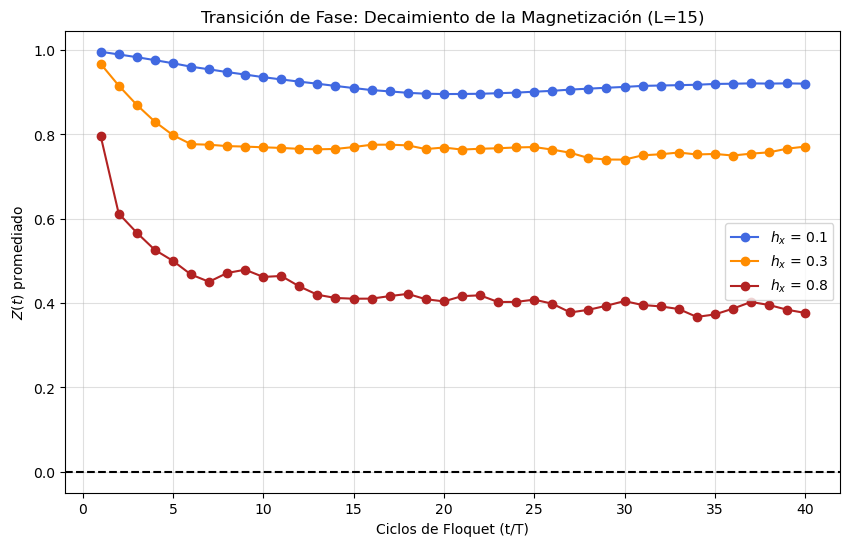

In [2]:
# ==========================================
# EXPERIMENTO: Barrido de la perturbación h_x
# ==========================================
L = 15
t0 = 1.0
t1 = np.pi / 2
J = 1.0
hz_max = 1.0
n_pasos = 40
realizaciones_desorden = 150 # Aumentar a 100+ para el reporte final

# Valores de perturbación a evaluar
hx_vals = [0.1, 0.3, 0.8] 
colores = ['royalblue', 'darkorange', 'firebrick']

plt.figure(figsize=(10, 6))

for hx, color in zip(hx_vals, colores):
    print(f"Evaluando perturbación h_x = {hx}...")
    Z_promedio = np.zeros(n_pasos)
    
    for semilla in range(realizaciones_desorden):
        Z_trayectoria = simulacion_mbl_floquet(
            L=L, t0=t0, t1=t1, J=J, hz_max=hz_max, hx_max=hx, 
            n_pasos=n_pasos, max_bond=50, cutoff=1e-8, seed=semilla
        )
        Z_promedio += Z_trayectoria
        
    Z_promedio /= realizaciones_desorden
    
    plt.plot(range(1, n_pasos + 1), Z_promedio, marker='o', color=color, label=f'$h_x$ = {hx}')

plt.axhline(0, color='black', linestyle='--')
plt.title(f'Transición de Fase: Decaimiento de la Magnetización (L={L})')
plt.xlabel('Ciclos de Floquet (t/T)')
plt.ylabel('$Z(t)$ promediado')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

Evaluando perturbación h_x = 0.1...


t=1, max-bond=3: 100%|##########| 100/100 [00:03<00:00, 28.24%/s]  


Evaluando perturbación h_x = 0.5...


t=1, max-bond=29: 100%|##########| 100/100 [00:04<00:00, 23.72%/s]  


Evaluando perturbación h_x = 0.9...


t=0.99, max-bond=50:  98%|#########8| 98/100 [00:07<00:00, 12.22%/s]/home/sebastorrub/anaconda3/lib/python3.13/site-packages/quimb/tensor/decomp.py:363: UserWarning: Got: Internal algorithm failed to converge., falling back to scipy gesvd driver.
  warnings.warn(f"Got: {e}, falling back to scipy gesvd driver.")
t=1, max-bond=50: 100%|##########| 100/100 [00:06<00:00, 16.55%/s]   


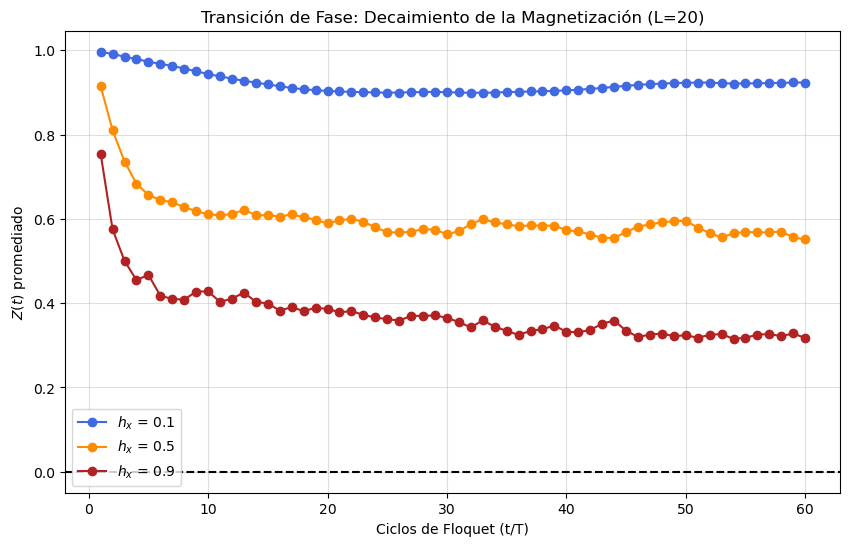

In [2]:
# ==========================================
# EXPERIMENTO: Barrido de la perturbación h_x
# ==========================================
L = 20
t0 = 1.0
t1 = np.pi / 2
J = 1.0
hz_max = 1.0
n_pasos = 60
realizaciones_desorden = 200 # Aumentar a 100+ para el reporte final

# Valores de perturbación a evaluar
hx_vals = [0.1, 0.5, 0.9] 
colores = ['royalblue', 'darkorange', 'firebrick']

plt.figure(figsize=(10, 6))

for hx, color in zip(hx_vals, colores):
    print(f"Evaluando perturbación h_x = {hx}...")
    Z_promedio = np.zeros(n_pasos)
    
    for semilla in range(realizaciones_desorden):
        Z_trayectoria = simulacion_mbl_floquet(
            L=L, t0=t0, t1=t1, J=J, hz_max=hz_max, hx_max=hx, 
            n_pasos=n_pasos, max_bond=50, cutoff=1e-8, seed=semilla
        )
        Z_promedio += Z_trayectoria
        
    Z_promedio /= realizaciones_desorden
    
    plt.plot(range(1, n_pasos + 1), Z_promedio, marker='o', color=color, label=f'$h_x$ = {hx}')

plt.axhline(0, color='black', linestyle='--')
plt.title(f'Transición de Fase: Decaimiento de la Magnetización (L={L})')
plt.xlabel('Ciclos de Floquet (t/T)')
plt.ylabel('$Z(t)$ promediado')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()